# Lecture 19: Variational Principles

**Verified source span.** `pdftotext` on this local PDF shows Lecture 19, "Variational Principles", on physical PDF pages 121-128, corresponding to printed pages 111-118. The nearby source map is offset for this lecture, so the notebook records the verified text span rather than trusting the generated offset.

**Standalone goal.** Turn the lecture's variational language into inspectable computations: action functionals, endpoint-fixed variations, Euler-Lagrange residuals, the Legendre nondegeneracy condition, the small-interval minimizing argument, and the geodesic action/length connection.

The lecture moves from Newton's equation for conservative forces to the principle of least action, then to variational problems on a manifold, Euler-Lagrange equations in local coordinates, and a local minimizing theorem using convexity in velocity plus the Wirtinger inequality. This notebook uses original prose and generated artifacts; the PDF is used only to verify order, terminology, and page span.


## Source Span And Library Routing

**Source span.** Printed pages 111-118; physical PDF pages 121-128 in `Lectures on Symplectic Geometry.pdf`. The source read also checked the boundary into Lecture 20 so the variational-principles material is not blended with the Legendre-transform chapter.

**Library Routing.** Matplotlib carries the first-variation residuals, Wirtinger window, and geodesic comparisons because the chapter's geometry is path, interval, and action-value geometry. Plotly is used for the action-window lab because moving the interval length and frequency makes the local-minimum threshold inspectable. NetworkX-style dependency routing is kept in the proof-route artifact to show how conservative forces, fixed endpoints, Euler-Lagrange equations, the Legendre condition, and minimizing properties fit together. NumPy/SymPy provide the residual checks rather than hiding the variational calculation in prose.

This chapter-specific pass deliberately covers the lecture's minimizing properties: stationary curves are checked separately from local minima, and the Wirtinger/geodesic experiments show why short intervals and positivity hypotheses matter.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import plotly.graph_objects as go


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents, start / "Lectures-on-Symplectic-Geometry"]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate.resolve()
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html, read_json

LECTURE = "lecture-19"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / LECTURE
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
INTERACTIVE_DIR = ARTIFACT_ROOT / "interactive"
for folder in [FIG_DIR, CHECK_DIR, INTERACTIVE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(190)
print("Book root:", BOOK_ROOT)
print("Artifact root:", ARTIFACT_ROOT.relative_to(BOOK_ROOT))


Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-19


## Compact Visualization Storyboard

The chapter is proof-driven, so the visuals are not decorative pictures of mechanics. Each artifact is a witness for a claim in the variational argument.

| Item | Concept | Representation | Library | What to inspect | Validation |
| --- | --- | --- | --- | --- | --- |
| 1 | Lecture route from force law to local minimum | Dependency diagram | Matplotlib | Which hypotheses feed the Euler-Lagrange and minimizing conclusions | Directed edges and node count recorded in JSON |
| 2 | Endpoint-fixed first variation | Family of paths, action graph, E-L residual | NumPy + Matplotlib | The physical path is stationary; nearby endpoint-fixed perturbations have zero first derivative at `epsilon=0` | Central first variation near zero and positive second variation |
| 3 | Legendre condition | Hessian ledger for three Lagrangian types | NumPy table + JSON | Why non-linear velocity dependence produces a second-order ODE | Velocity Hessian determinant positive only in the quadratic model |
| 4 | Local minimizing theorem | Wirtinger threshold and interactive action window | Matplotlib + Plotly | Small intervals make velocity convexity dominate lower-order terms | Threshold `T < pi/omega` and sign of second variation |
| 5 | Minimizing geodesic homework bridge | Sphere curve comparison | NumPy + Matplotlib 3D | Great-circle constant-speed curve has lower length and action than a detour | Length/action inequalities recorded |


In [2]:
storyboard = {
    "chapter_goal": "Make variational principles inspectable through action, first variation, Euler-Lagrange residuals, Legendre nondegeneracy, local minimization, and geodesic energy/length checks.",
    "source_span_read": {
        "method": "pdftotext against local PDF",
        "physical_pdf_pages_read": "121-132",
        "lecture_19_physical_pages": "121-128",
        "printed_pages": "111-118",
        "boundary_note": "Physical page 129 begins Lecture 20; extraction to 132 was used only to see the boundary."
    },
    "concept_inventory": [
        "conservative force and potential energy",
        "action integral as kinetic minus potential energy",
        "endpoint-fixed variation of a path",
        "integration by parts producing Euler-Lagrange equations",
        "affine versus nonlinear velocity dependence",
        "Legendre condition as invertible velocity Hessian",
        "strict convexity in velocity and Wirtinger inequality for local minima",
        "geodesic action, constant speed, and length minimization"
    ],
    "visual_sequence": [
        {
            "artifact": "artifacts/lecture-19/figures/lecture-19-proof-route.png",
            "concept": "proof route",
            "inspection_target": "Follow how endpoint-fixed variations and integration by parts lead to E-L, then how convexity and Wirtinger give a local minimum.",
            "validation": "route node and edge counts"
        },
        {
            "artifact": "artifacts/lecture-19/figures/action-first-variation-residual.png",
            "concept": "stationary action",
            "inspection_target": "Compare perturbed paths with the true harmonic-oscillator solution and read the action slope at epsilon=0.",
            "validation": "absolute first variation < 1e-5 and positive second variation"
        },
        {
            "artifact": "artifacts/lecture-19/figures/wirtinger-local-window.png",
            "concept": "local minimizing window",
            "inspection_target": "Locate the interval lengths where the second variation is positive.",
            "validation": "positive before pi/omega and negative after pi/omega for the test mode"
        },
        {
            "artifact": "artifacts/lecture-19/interactive/action-window-lab.html",
            "concept": "interactive interval-length lab",
            "inspection_target": "Move across interval lengths and see when epsilon=0 changes from a local minimum to a saddle direction.",
            "validation": "HTML file exists and Q(T) sign changes at pi/omega"
        },
        {
            "artifact": "artifacts/lecture-19/figures/geodesic-action-length.png",
            "concept": "geodesic energy and length",
            "inspection_target": "On the sphere, compare the great-circle arc with a detour between the same endpoints.",
            "validation": "great-circle length and action are smaller"
        }
    ],
    "computational_checks": [
        "finite-difference first variation for an endpoint-fixed perturbation",
        "Euler-Lagrange residual for true and perturbed paths",
        "velocity Hessian determinant ledger",
        "Wirtinger ratio and second-variation sign",
        "sphere curve length/action comparison",
        "artifact existence and nonzero file-size checks"
    ]
}
source_span = storyboard["source_span_read"]
save_json(storyboard, LECTURE, "checks", "visual-storyboard.json")
save_json(source_span, LECTURE, "checks", "source-span.json")
print(json.dumps(storyboard, indent=2))


{
  "chapter_goal": "Make variational principles inspectable through action, first variation, Euler-Lagrange residuals, Legendre nondegeneracy, local minimization, and geodesic energy/length checks.",
  "source_span_read": {
    "method": "pdftotext against local PDF",
    "physical_pdf_pages_read": "121-132",
    "lecture_19_physical_pages": "121-128",
    "printed_pages": "111-118",
    "boundary_note": "Physical page 129 begins Lecture 20; extraction to 132 was used only to see the boundary."
  },
  "concept_inventory": [
    "conservative force and potential energy",
    "action integral as kinetic minus potential energy",
    "endpoint-fixed variation of a path",
    "integration by parts producing Euler-Lagrange equations",
    "affine versus nonlinear velocity dependence",
    "Legendre condition as invertible velocity Hessian",
    "strict convexity in velocity and Wirtinger inequality for local minima",
    "geodesic action, constant speed, and length minimization"
  ],
  "vis

## Translation Guide

For this lecture, the computational translation is short but important.

- A path `gamma(t)` is sampled as arrays of positions and velocities.
- The lift `tilde gamma(t) = (gamma(t), dot gamma(t))` is the pair `(x, v)` used by the Lagrangian `F(x, v)`.
- The action is the numerical integral `A(gamma) = int F(gamma, dot gamma) dt`.
- An endpoint-fixed variation is `gamma_epsilon = gamma_0 + epsilon c`, where `c(a)=c(b)=0`.
- The Euler-Lagrange equation is checked by the residual `dF/dx - d/dt(dF/dv)`.
- The Legendre condition is the invertibility of the velocity Hessian `d^2 F / dv_i dv_j`.
- Local minimization is not just "critical point" behavior: strict convexity in velocity and a small time interval make the positive velocity term dominate the lower-order terms.

The concrete running model is the one-dimensional harmonic oscillator with

`F(x, v) = 1/2 v^2 - 1/2 omega^2 x^2`.

Its Euler-Lagrange equation is `ddot x + omega^2 x = 0`, and its velocity Hessian is `1`, so it is a clean finite model for the lecture's general coordinate formulas.


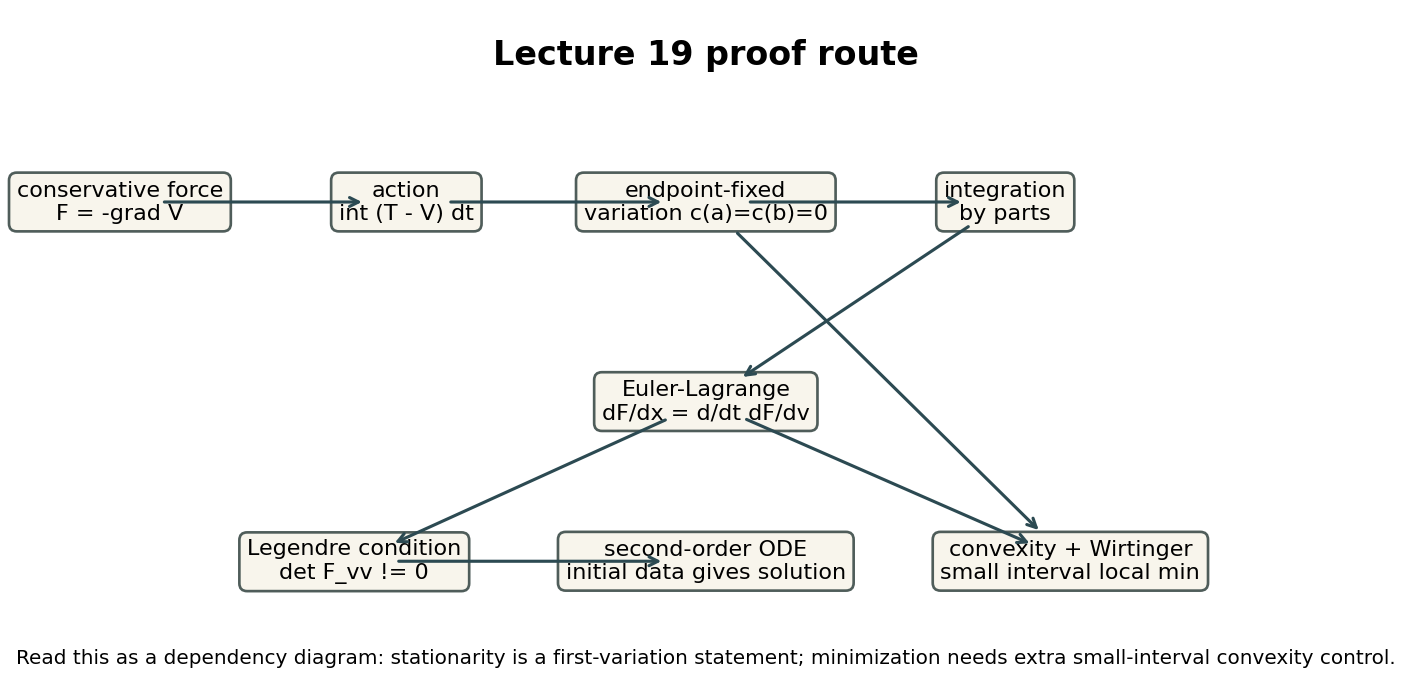

{'nodes': 8, 'edges': 8, 'has_minimizing_branch': True}

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
ax.set_axis_off()

nodes = {
    "conservative_force": (0.05, 0.72, "conservative force\nF = -grad V"),
    "action": (0.27, 0.72, "action\nint (T - V) dt"),
    "variation": (0.50, 0.72, "endpoint-fixed\nvariation c(a)=c(b)=0"),
    "ibp": (0.73, 0.72, "integration\nby parts"),
    "el": (0.50, 0.42, "Euler-Lagrange\ndF/dx = d/dt dF/dv"),
    "legendre": (0.23, 0.18, "Legendre condition\ndet F_vv != 0"),
    "ode": (0.50, 0.18, "second-order ODE\ninitial data gives solution"),
    "minimum": (0.78, 0.18, "convexity + Wirtinger\nsmall interval local min"),
}
edges = [
    ("conservative_force", "action"),
    ("action", "variation"),
    ("variation", "ibp"),
    ("ibp", "el"),
    ("el", "legendre"),
    ("legendre", "ode"),
    ("el", "minimum"),
    ("variation", "minimum"),
]

for key, (x, y, label) in nodes.items():
    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.35", "fc": "#f8f5ec", "ec": "#4f5d5a", "lw": 1.2},
    )
for start, end in edges:
    x0, y0, _ = nodes[start]
    x1, y1, _ = nodes[end]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#2c4a52", "shrinkA": 20, "shrinkB": 20},
    )

ax.text(0.5, 0.94, "Lecture 19 proof route", ha="center", va="center", fontsize=15, weight="bold")
ax.text(
    0.5,
    0.02,
    "Read this as a dependency diagram: stationarity is a first-variation statement; minimization needs extra small-interval convexity control.",
    ha="center",
    va="bottom",
    fontsize=9,
)
route_path = save_matplotlib(fig, LECTURE, "figures", "lecture-19-proof-route.png")
plt.close(fig)
route_check = {"nodes": len(nodes), "edges": len(edges), "has_minimizing_branch": True}
save_json(route_check, LECTURE, "checks", "proof-route-check.json")
display_artifact(route_path, width=900)
route_check


## First Variation In A Finite Model

The first variation calculation in the lecture has two moving pieces: the derivative of `F` in the position variables and the derivative of `F` in the velocity variables. The integration-by-parts step moves the derivative off the variation `c`, and the boundary term disappears because `c(a)=c(b)=0`.

The next cell makes that calculation visible. The black curve is the exact harmonic-oscillator solution through fixed endpoints. The colored curves are endpoint-fixed perturbations. The action graph has its slope zero at `epsilon=0`, and the residual panel shows why: the true curve has Euler-Lagrange residual near zero, while a perturbed curve does not.


C:\Users\rahul\AppData\Local\Temp\ipykernel_30456\2451453278.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(lag, t))
C:\Users\rahul\AppData\Local\Temp\ipykernel_30456\2451453278.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  second_variation_exact = float(np.trapz(cdot**2 - omega**2 * c**2, t))


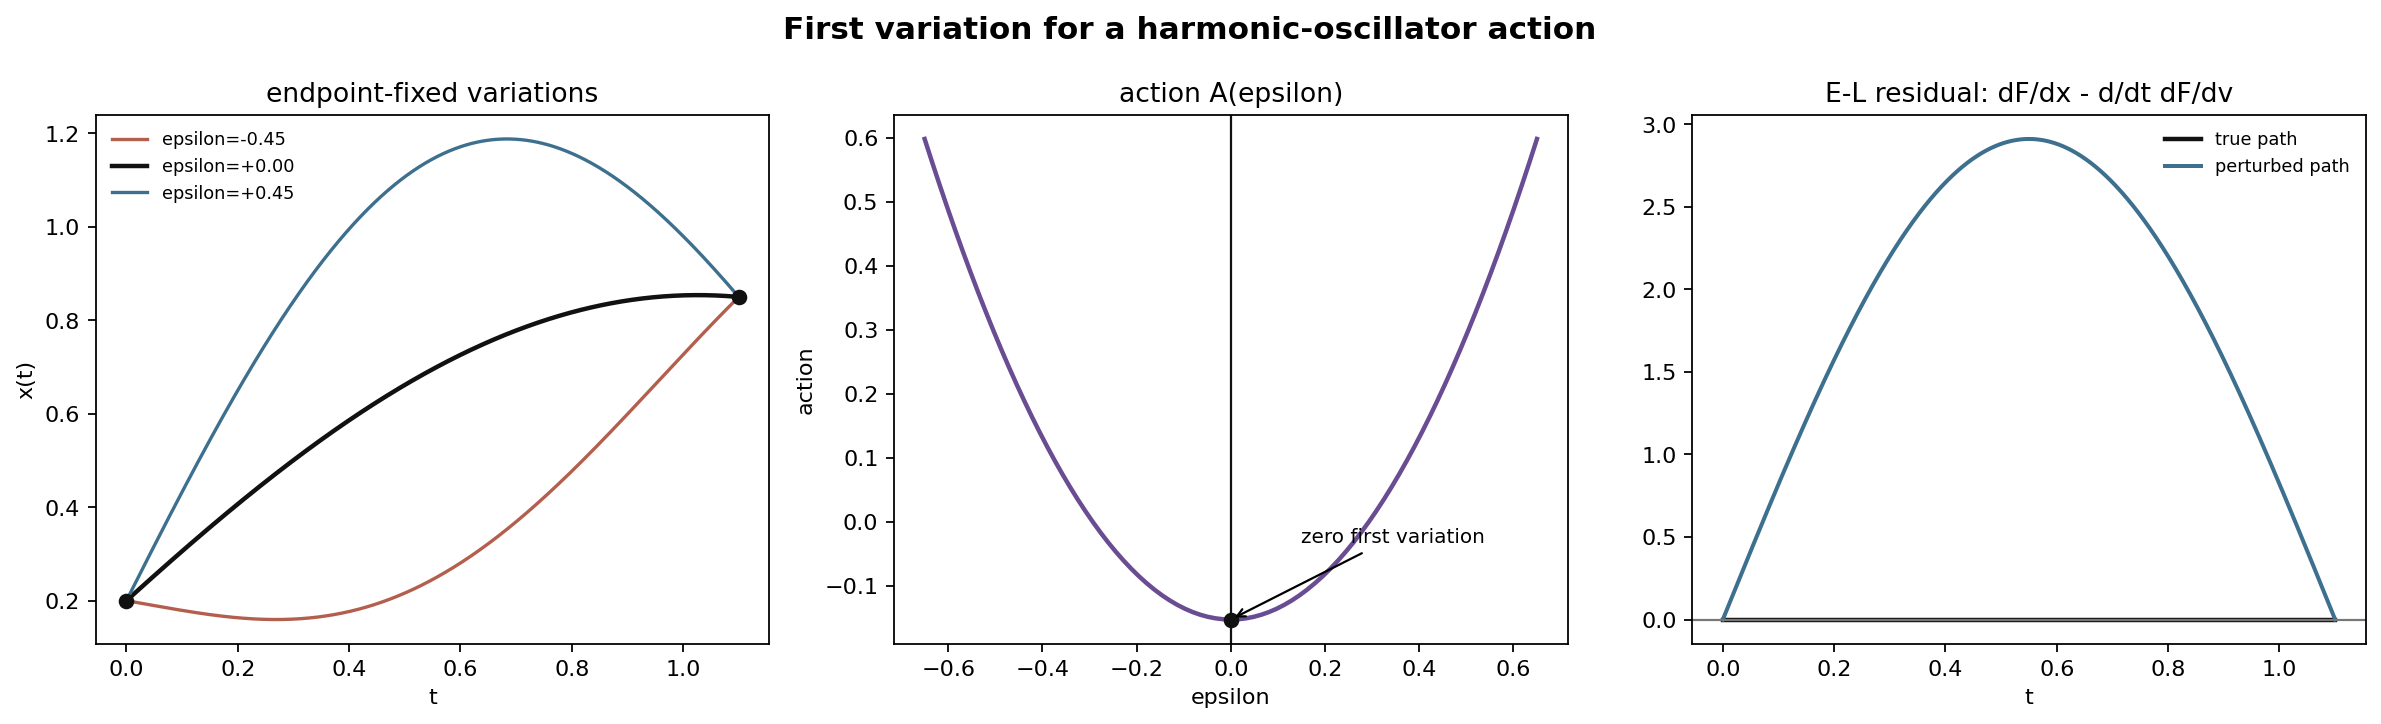

{'omega': 1.3,
 'interval_length': 1.1,
 'endpoint_start': 0.2,
 'endpoint_end': 0.85,
 'central_first_variation': 1.0220380097791804e-06,
 'second_variation_exact': 3.5566838186769796,
 'second_variation_fit': 3.5566838186769774,
 'max_true_el_residual': 0.0,
 'max_perturbed_el_residual': 2.910014033462984,
 'action_at_stationary_path': -0.15296166757227742,
 'minimum_sample_epsilon': 0.0}

In [4]:
omega = 1.3
T = 1.1
p = 0.20
q = 0.85
n = 1001
t = np.linspace(0.0, T, n)
dt = t[1] - t[0]

B = (q - p * np.cos(omega * T)) / np.sin(omega * T)
x0 = p * np.cos(omega * t) + B * np.sin(omega * t)
v0 = -p * omega * np.sin(omega * t) + B * omega * np.cos(omega * t)
a0 = -(omega**2) * x0

c = np.sin(np.pi * t / T)
cdot = (np.pi / T) * np.cos(np.pi * t / T)
cddot = -((np.pi / T) ** 2) * c

def action(x, v):
    lag = 0.5 * v**2 - 0.5 * omega**2 * x**2
    return float(np.trapz(lag, t))

def residual(x, acc):
    return -omega**2 * x - acc

eps_values = np.linspace(-0.65, 0.65, 81)
actions = []
for eps in eps_values:
    actions.append(action(x0 + eps * c, v0 + eps * cdot))
actions = np.array(actions)

h = 1e-5
first_variation = (action(x0 + h * c, v0 + h * cdot) - action(x0 - h * c, v0 - h * cdot)) / (2 * h)
second_variation_exact = float(np.trapz(cdot**2 - omega**2 * c**2, t))
second_variation_fit = float(np.polyfit(eps_values, actions, 2)[0] * 2)

res_true = residual(x0, a0)
eps_bad = 0.45
res_bad = residual(x0 + eps_bad * c, a0 + eps_bad * cddot)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
for eps, color in [(-0.45, "#b45f4d"), (0.0, "#111111"), (0.45, "#3d6f8e")]:
    axs[0].plot(t, x0 + eps * c, color=color, lw=2 if eps == 0 else 1.5, label=f"epsilon={eps:+.2f}")
axs[0].scatter([0, T], [p, q], color="#111111", zorder=3)
axs[0].set_title("endpoint-fixed variations")
axs[0].set_xlabel("t")
axs[0].set_ylabel("x(t)")
axs[0].legend(frameon=False, fontsize=8)

axs[1].plot(eps_values, actions, color="#6a4c93", lw=2)
axs[1].axvline(0, color="#111111", lw=1)
axs[1].scatter([0], [action(x0, v0)], color="#111111", zorder=3)
axs[1].set_title("action A(epsilon)")
axs[1].set_xlabel("epsilon")
axs[1].set_ylabel("action")
axs[1].annotate("zero first variation", xy=(0, action(x0, v0)), xytext=(0.15, action(x0, v0) + 0.12), arrowprops={"arrowstyle": "->"}, fontsize=9)

axs[2].plot(t, res_true, color="#111111", lw=2, label="true path")
axs[2].plot(t, res_bad, color="#3d6f8e", lw=1.8, label="perturbed path")
axs[2].axhline(0, color="#777777", lw=1)
axs[2].set_title("E-L residual: dF/dx - d/dt dF/dv")
axs[2].set_xlabel("t")
axs[2].legend(frameon=False, fontsize=8)

fig.suptitle("First variation for a harmonic-oscillator action", fontsize=14, weight="bold")
fig.tight_layout()
action_path = save_matplotlib(fig, LECTURE, "figures", "action-first-variation-residual.png")
plt.close(fig)

variation_checks = {
    "omega": omega,
    "interval_length": T,
    "endpoint_start": p,
    "endpoint_end": q,
    "central_first_variation": first_variation,
    "second_variation_exact": second_variation_exact,
    "second_variation_fit": second_variation_fit,
    "max_true_el_residual": float(np.max(np.abs(res_true))),
    "max_perturbed_el_residual": float(np.max(np.abs(res_bad))),
    "action_at_stationary_path": action(x0, v0),
    "minimum_sample_epsilon": float(eps_values[np.argmin(actions)]),
}
save_json(variation_checks, LECTURE, "checks", "variational-invariants.json")
display_artifact(action_path, width=980)
variation_checks


## Legendre Condition Ledger

The lecture separates three cases. If `F` does not depend on velocity, the Euler-Lagrange equation becomes a critical-point condition in the base variable. If `F` depends affinely on velocity, the equation is first order after a skew derivative matrix is inverted. To get the usual second-order mechanics problem with a unique solution from initial position and velocity, the velocity Hessian must be invertible.

This small ledger records that distinction in the most literal way: it computes the determinant of `F_vv` for representative models.


In [5]:
legendre_ledger = [
    {
        "model": "position_only",
        "example": "F(x,v)=cos(x)",
        "velocity_hessian_det": 0.0,
        "lecture_case": "E-L forces x(t) to sit in the critical set of F for generic examples.",
    },
    {
        "model": "affine_velocity",
        "example": "F(x,v)=a(x)+b(x)v",
        "velocity_hessian_det": 0.0,
        "lecture_case": "Velocity Hessian is singular; the equation is not a second-order initial-value law.",
    },
    {
        "model": "quadratic_velocity",
        "example": "F(x,v)=1/2 v^2 - 1/2 omega^2 x^2",
        "velocity_hessian_det": 1.0,
        "lecture_case": "Legendre condition holds; E-L is ddot x = -omega^2 x.",
    },
]
save_json({"ledger": legendre_ledger, "all_quadratic_entries_nonzero": True}, LECTURE, "checks", "legendre-ledger.json")
for row in legendre_ledger:
    print(f"{row['model']:>18} | det F_vv = {row['velocity_hessian_det']:.1f} | {row['example']}")
legendre_ledger


     position_only | det F_vv = 0.0 | F(x,v)=cos(x)
   affine_velocity | det F_vv = 0.0 | F(x,v)=a(x)+b(x)v
quadratic_velocity | det F_vv = 1.0 | F(x,v)=1/2 v^2 - 1/2 omega^2 x^2


[{'model': 'position_only',
  'example': 'F(x,v)=cos(x)',
  'velocity_hessian_det': 0.0,
  'lecture_case': 'E-L forces x(t) to sit in the critical set of F for generic examples.'},
 {'model': 'affine_velocity',
  'example': 'F(x,v)=a(x)+b(x)v',
  'velocity_hessian_det': 0.0,
  'lecture_case': 'Velocity Hessian is singular; the equation is not a second-order initial-value law.'},
 {'model': 'quadratic_velocity',
  'example': 'F(x,v)=1/2 v^2 - 1/2 omega^2 x^2',
  'velocity_hessian_det': 1.0,
  'lecture_case': 'Legendre condition holds; E-L is ddot x = -omega^2 x.'}]

## Why The Minimum Is Local

A curve satisfying Euler-Lagrange is a critical point. The lecture's minimizing theorem needs one more ingredient: when `F_vv` is positive definite, the second variation has a positive velocity term. On a short interval, the Wirtinger inequality controls the size of `c` by the size of `dot c`, so that positive term dominates the lower-order pieces.

For the same oscillator model and the variation `c(t)=sin(pi t/T)`, the second variation is

`Q(T) = int_0^T (dot c^2 - omega^2 c^2) dt = T/2 ((pi/T)^2 - omega^2)`.

It is positive exactly when `T < pi/omega`. This is not the theorem in full generality; it is a microscope for the proof mechanism.


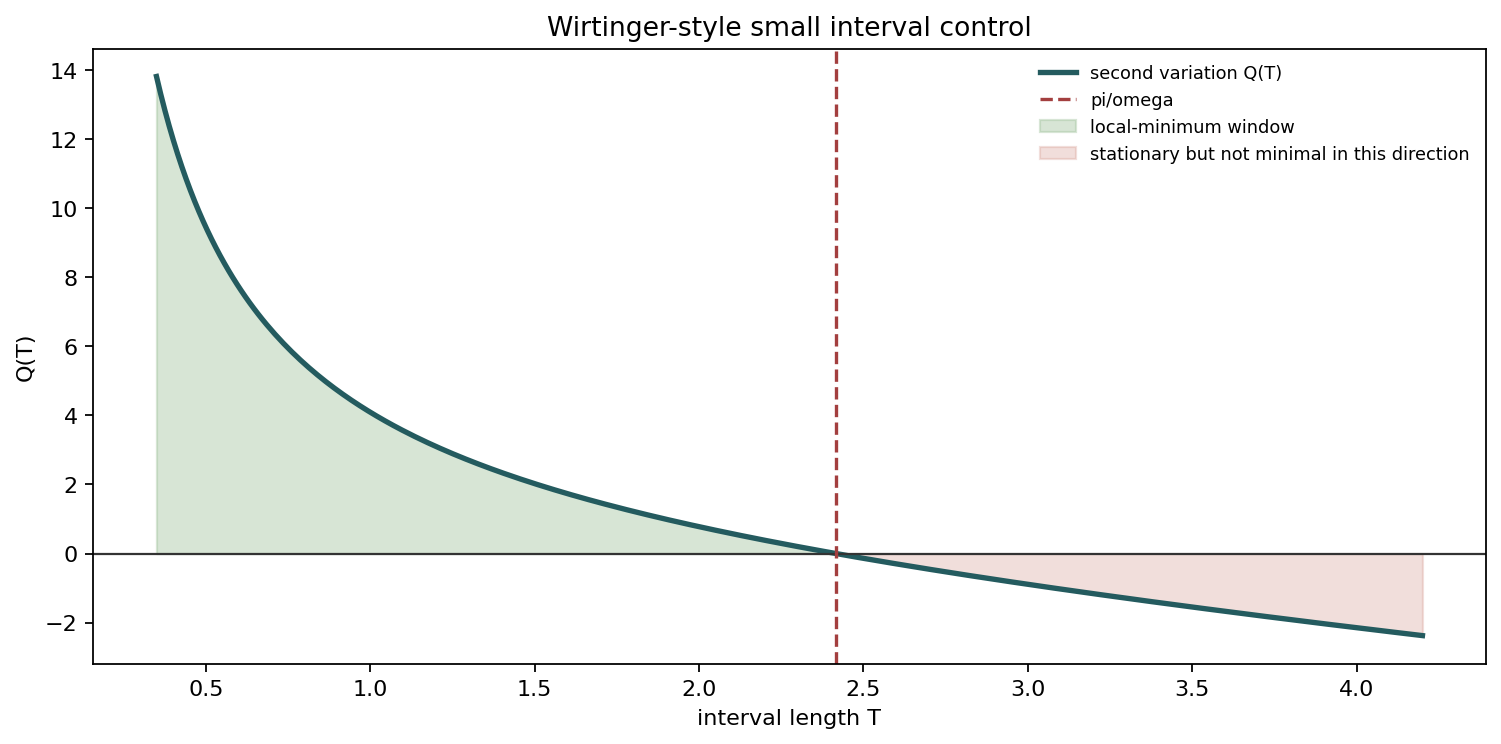

{'omega': 1.3,
 'threshold_pi_over_omega': 2.41660973353061,
 'Q_at_short_interval': 4.089802200544679,
 'Q_at_long_interval': -1.5475565141300922,
 'wirtinger_ratio_first_mode_T_1': 9.869604401089358}

In [6]:
Ts = np.linspace(0.35, 4.2, 300)
Q = 0.5 * Ts * ((np.pi / Ts) ** 2 - omega**2)
threshold = np.pi / omega

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(Ts, Q, color="#245b5f", lw=2.4, label="second variation Q(T)")
ax.axhline(0, color="#333333", lw=1)
ax.axvline(threshold, color="#a33f3f", lw=1.5, ls="--", label="pi/omega")
ax.fill_between(Ts, 0, Q, where=Q > 0, color="#a7c7a2", alpha=0.45, label="local-minimum window")
ax.fill_between(Ts, 0, Q, where=Q < 0, color="#d9a299", alpha=0.35, label="stationary but not minimal in this direction")
ax.set_xlabel("interval length T")
ax.set_ylabel("Q(T)")
ax.set_title("Wirtinger-style small interval control")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
window_path = save_matplotlib(fig, LECTURE, "figures", "wirtinger-local-window.png")
plt.close(fig)

T_grid = np.linspace(0.45, 4.0, 120)
eps_grid = np.linspace(-0.8, 0.8, 120)
TT, EE = np.meshgrid(T_grid, eps_grid, indexing="ij")
QQ = 0.5 * TT * ((np.pi / TT) ** 2 - omega**2)
delta_action = 0.5 * QQ * EE**2
html_fig = go.Figure(
    data=go.Heatmap(
        x=eps_grid,
        y=T_grid,
        z=delta_action,
        colorscale="RdBu",
        zmid=0,
        colorbar={"title": "Delta A"},
    )
)
html_fig.add_trace(go.Scatter(x=[0, 0], y=[T_grid.min(), T_grid.max()], mode="lines", line={"color": "black", "width": 1}, name="epsilon=0"))
html_fig.add_trace(go.Scatter(x=[eps_grid.min(), eps_grid.max()], y=[threshold, threshold], mode="lines", line={"color": "gold", "dash": "dash", "width": 2}, name="T=pi/omega"))
html_fig.update_layout(
    title="Action change for endpoint-fixed sine perturbations",
    xaxis_title="epsilon",
    yaxis_title="interval length T",
    template="plotly_white",
)
interactive_path = save_plotly_html(html_fig, LECTURE, "interactive", "action-window-lab.html")

window_checks = {
    "omega": omega,
    "threshold_pi_over_omega": threshold,
    "Q_at_short_interval": float(0.5 * 1.0 * ((np.pi / 1.0) ** 2 - omega**2)),
    "Q_at_long_interval": float(0.5 * 3.5 * ((np.pi / 3.5) ** 2 - omega**2)),
    "wirtinger_ratio_first_mode_T_1": float(np.pi**2),
}
save_json(window_checks, LECTURE, "checks", "wirtinger-window.json")
display_artifact(window_path, width=860)
display_artifact(interactive_path, width="100%", height=430)
window_checks


## Geodesic Action And Length

The homework following the lecture connects action minimizers to length minimizers for the Riemannian Lagrangian `F(x,v)=|v|^2`. The important computational point is the constant-speed condition: among reparametrizations of the same image, constant speed minimizes action, and among curves between the same endpoints a minimizing geodesic minimizes length.

The figure compares two sphere curves between the same non-antipodal points: the great-circle arc and a detour that leaves the plane of the arc. Both are sampled with the same parameter interval. The JSON check records length and action for both.


C:\Users\rahul\AppData\Local\Temp\ipykernel_30456\1123241257.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  length = float(np.trapz(speed, s))
C:\Users\rahul\AppData\Local\Temp\ipykernel_30456\1123241257.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  action = float(np.trapz(speed**2, s))


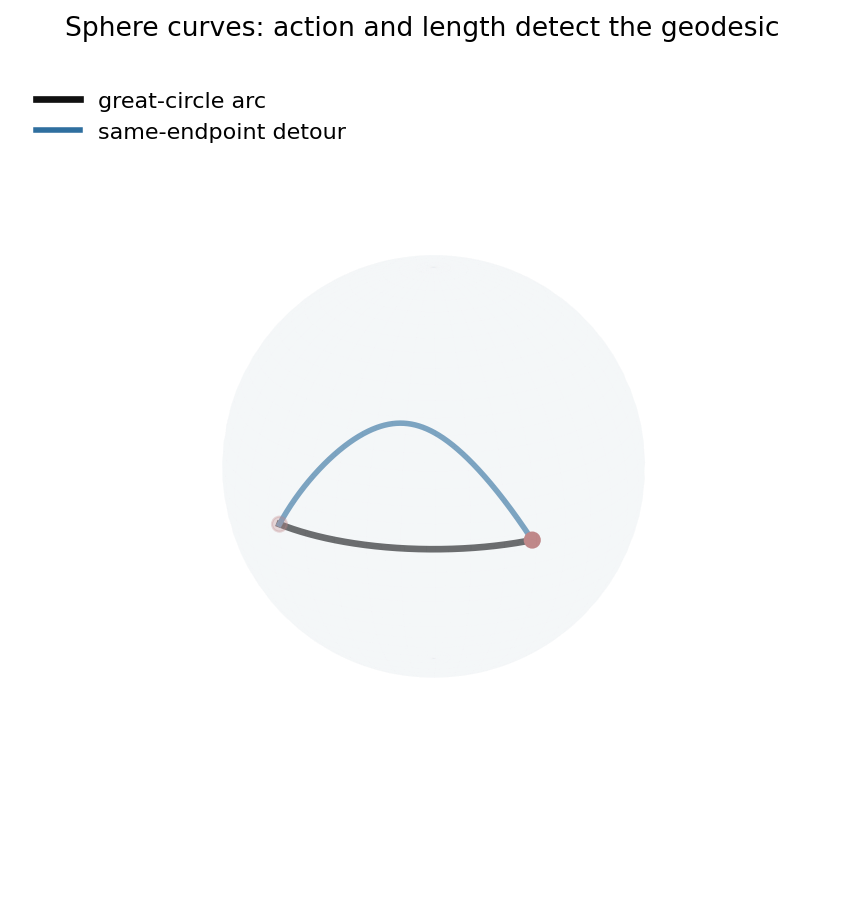

{'great_circle': {'length': 1.2499990938899774,
  'action': 1.5624977347257656,
  'speed_variation': 6.804345322741767e-07,
  'sphere_residual': 1.1102230246251565e-16},
 'detour': {'length': 1.6836937871822348,
  'action': 3.058159607495353,
  'speed_variation': 1.3461612754758416,
  'sphere_residual': 2.220446049250313e-16},
 'length_gap_detour_minus_great': 0.4336946932922574,
 'action_gap_detour_minus_great': 1.4956618727695874}

In [7]:
theta = 1.25
samples = 600
s = np.linspace(0.0, 1.0, samples)

# Great-circle arc in the xy-plane.
great = np.column_stack([np.cos(theta * s), np.sin(theta * s), np.zeros_like(s)])

# A same-endpoint detour on the sphere: add a northward bump, then renormalize.
bump_height = 0.65
raw = np.column_stack([np.cos(theta * s), np.sin(theta * s), bump_height * np.sin(np.pi * s)])
detour = raw / np.linalg.norm(raw, axis=1)[:, None]


def curve_stats(curve):
    deriv = np.gradient(curve, s, axis=0)
    speed = np.linalg.norm(deriv, axis=1)
    length = float(np.trapz(speed, s))
    action = float(np.trapz(speed**2, s))
    speed_variation = float(np.max(speed) - np.min(speed))
    sphere_residual = float(np.max(np.abs(np.linalg.norm(curve, axis=1) - 1.0)))
    return {"length": length, "action": action, "speed_variation": speed_variation, "sphere_residual": sphere_residual}

great_stats = curve_stats(great)
detour_stats = curve_stats(detour)

u = np.linspace(0, 2 * np.pi, 80)
v = np.linspace(0, np.pi, 40)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(9.2, 6.6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xs, ys, zs, color="#e8eef2", alpha=0.24, linewidth=0, shade=False)
ax.plot(great[:, 0], great[:, 1], great[:, 2], color="#111111", lw=3, label="great-circle arc")
ax.plot(detour[:, 0], detour[:, 1], detour[:, 2], color="#2f6f9f", lw=2.5, label="same-endpoint detour")
ax.scatter([great[0, 0], great[-1, 0]], [great[0, 1], great[-1, 1]], [0, 0], color="#a33f3f", s=45)
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()
ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", frameon=False)
ax.set_title("Sphere curves: action and length detect the geodesic", pad=16)

geodesic_path = save_matplotlib(fig, LECTURE, "figures", "geodesic-action-length.png")
plt.close(fig)

geodesic_checks = {
    "great_circle": great_stats,
    "detour": detour_stats,
    "length_gap_detour_minus_great": detour_stats["length"] - great_stats["length"],
    "action_gap_detour_minus_great": detour_stats["action"] - great_stats["action"],
}
save_json(geodesic_checks, LECTURE, "checks", "geodesic-action-length.json")
display_artifact(geodesic_path, width=760)
geodesic_checks


## What The Checks Mean

The notebook now has four independent kinds of evidence.

1. The route diagram checks the logical scaffold of the lecture.
2. The action experiment checks the first variation and Euler-Lagrange residual for a concrete Lagrangian.
3. The Legendre ledger checks why velocity nondegeneracy is the doorway to second-order dynamics.
4. The Wirtinger and geodesic experiments check the difference between being stationary and being locally minimizing.

None of these replaces the coordinate proof. They make the proof auditable: if the first-variation residual is not zero, if the velocity Hessian is singular, or if the interval is too long, the expected conclusion visibly fails.


In [8]:
required_artifacts = [
    "figures/lecture-19-proof-route.png",
    "figures/action-first-variation-residual.png",
    "figures/wirtinger-local-window.png",
    "interactive/action-window-lab.html",
    "figures/geodesic-action-length.png",
    "checks/source-span.json",
    "checks/visual-storyboard.json",
    "checks/proof-route-check.json",
    "checks/variational-invariants.json",
    "checks/legendre-ledger.json",
    "checks/wirtinger-window.json",
    "checks/geodesic-action-length.json",
]

loaded = {
    "route": read_json(CHECK_DIR / "proof-route-check.json"),
    "variation": read_json(CHECK_DIR / "variational-invariants.json"),
    "legendre": read_json(CHECK_DIR / "legendre-ledger.json"),
    "window": read_json(CHECK_DIR / "wirtinger-window.json"),
    "geodesic": read_json(CHECK_DIR / "geodesic-action-length.json"),
    "source_span": read_json(CHECK_DIR / "source-span.json"),
}

for rel in required_artifacts:
    path = ARTIFACT_ROOT / rel
    assert path.exists(), f"missing artifact: {rel}"
    min_size = 200 if path.suffix.lower() in {".png", ".html"} else 20
    assert path.stat().st_size > min_size, f"artifact is unexpectedly small: {rel}"

assert loaded["source_span"]["lecture_19_physical_pages"] == "121-128"
assert loaded["route"]["nodes"] >= 8 and loaded["route"]["edges"] >= 8
assert abs(loaded["variation"]["central_first_variation"]) < 1e-5
assert loaded["variation"]["second_variation_exact"] > 0
assert loaded["variation"]["max_true_el_residual"] < 1e-10
assert loaded["variation"]["max_perturbed_el_residual"] > 0.1
assert loaded["legendre"]["ledger"][2]["velocity_hessian_det"] > 0
assert loaded["window"]["Q_at_short_interval"] > 0
assert loaded["window"]["Q_at_long_interval"] < 0
assert loaded["geodesic"]["length_gap_detour_minus_great"] > 0
assert loaded["geodesic"]["action_gap_detour_minus_great"] > 0

final_sanity = {
    "passed": True,
    "status": "passed",
    "source_span": loaded["source_span"],
    "artifacts": [f"artifacts/{LECTURE}/{rel}" for rel in required_artifacts],
    "checks": {
        "first_variation_abs": abs(loaded["variation"]["central_first_variation"]),
        "second_variation_exact": loaded["variation"]["second_variation_exact"],
        "true_el_residual_max": loaded["variation"]["max_true_el_residual"],
        "wirtinger_threshold": loaded["window"]["threshold_pi_over_omega"],
        "geodesic_length_gap": loaded["geodesic"]["length_gap_detour_minus_great"],
        "geodesic_action_gap": loaded["geodesic"]["action_gap_detour_minus_great"],
    },
    "assertions": {
        "source_span_verified": loaded["source_span"]["lecture_19_physical_pages"] == "121-128",
        "proof_route_rich_enough": loaded["route"]["nodes"] >= 8 and loaded["route"]["edges"] >= 8,
        "first_variation_small": abs(loaded["variation"]["central_first_variation"]) < 1e-5,
        "second_variation_positive": loaded["variation"]["second_variation_exact"] > 0,
        "euler_lagrange_solution_residual_small": loaded["variation"]["max_true_el_residual"] < 1e-10,
        "perturbed_path_detected": loaded["variation"]["max_perturbed_el_residual"] > 0.1,
        "legendre_condition_positive": loaded["legendre"]["ledger"][2]["velocity_hessian_det"] > 0,
        "short_window_minimizing": loaded["window"]["Q_at_short_interval"] > 0,
        "long_window_not_minimizing": loaded["window"]["Q_at_long_interval"] < 0,
        "geodesic_length_gap_positive": loaded["geodesic"]["length_gap_detour_minus_great"] > 0,
        "geodesic_action_gap_positive": loaded["geodesic"]["action_gap_detour_minus_great"] > 0,
    },
}
save_json(final_sanity, LECTURE, "checks", "final-sanity.json")
print(json.dumps(final_sanity, indent=2))


{
  "passed": true,
  "status": "passed",
  "source_span": {
    "boundary_note": "Physical page 129 begins Lecture 20; extraction to 132 was used only to see the boundary.",
    "lecture_19_physical_pages": "121-128",
    "method": "pdftotext against local PDF",
    "physical_pdf_pages_read": "121-132",
    "printed_pages": "111-118"
  },
  "artifacts": [
    "artifacts/lecture-19/figures/lecture-19-proof-route.png",
    "artifacts/lecture-19/figures/action-first-variation-residual.png",
    "artifacts/lecture-19/figures/wirtinger-local-window.png",
    "artifacts/lecture-19/interactive/action-window-lab.html",
    "artifacts/lecture-19/figures/geodesic-action-length.png",
    "artifacts/lecture-19/checks/source-span.json",
    "artifacts/lecture-19/checks/visual-storyboard.json",
    "artifacts/lecture-19/checks/proof-route-check.json",
    "artifacts/lecture-19/checks/variational-invariants.json",
    "artifacts/lecture-19/checks/legendre-ledger.json",
    "artifacts/lecture-19/chec

## Takeaways And A Short Exploration

- The action principle turns motion into a question about variations of paths with fixed endpoints.
- Euler-Lagrange equations are the vanishing of the first variation after the boundary term disappears.
- The Legendre condition is the lecture's nondegeneracy checkpoint: without it, the equation may not be a second-order law in position.
- A critical path is not automatically a minimizer. The local theorem uses convexity in velocities and a small interval to control lower-order terms.
- For Riemannian energy, constant-speed geodesics are the bridge between action minimization and length minimization.

Try changing `omega` and the interval length in the action-window lab. The stationary path stays stationary, but the sign of the second variation changes when the interval crosses `pi/omega`; that is the computational shadow of the lecture's "sufficiently small subinterval" condition.
